## FLOW ANALYST THAT SHOULD I DO

1. Business Understanding
2. Import Libraries & Load Data
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Exploratory Data Analysis (EDA)
6. Statistical Analysis on Payment & Cancellation Behavior
7. Cancellation & Operational Risk Analysis
8. Time Series & Seasonal Trend Analysis
9. Regional Revenue & Logistics Analysis
10. Business Insights & Recommendations
11. Export Clean Dataset for Tableau Dashboard

## SECTION 1: BUSINESS UNDERSTANDING

PROBLEM STATEMENT:
E-commerce platform faces three key challenges:
1. High cancellation rate impacting revenue
2. Suboptimal payment method adoption strategy  
3. Inefficient logistics costing in Eastern Indonesia

BUSINESS QUESTIONS:
1. Does payment method significantly affect transaction value?
2. What are the main drivers of order cancellation?
3. Which provinces have the highest logistics cost burden?
4. Are there seasonal patterns in purchasing behavior?

HYPOTHESES:
- H1: Digital payment users have higher average order value than COD users
- H2: Higher shipping cost is positively correlated with cancellation rate
- H3: Eastern Indonesia provinces have higher logistics costs

In [1]:
# SECTION 2: IMPORT LIBRARIES & LOAD DATA 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import ttest_ind, chi2_contingency, pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)


# LOAD CSV WITH CORRECT SEPARATOR (;)

file_path = r'C:\Users\userr\OneDrive\Documents\Indonesia E - commerce sales & shipping\all_months_clean.csv'

# Load with semicolon separator
df = pd.read_csv(
    file_path,
    sep=';',  # ← PENTING: separator titik koma
    on_bad_lines='skip'
)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())

# Check date column
if 'Waktu Pesanan Dibuat' in df.columns:
    print(f"\nDate column found!")
    print(f"First 5 raw values:")
    print(df['Waktu Pesanan Dibuat'].head(5))
    
    # Convert to datetime
    df['Waktu Pesanan Dibuat'] = pd.to_datetime(
        df['Waktu Pesanan Dibuat'],
        format='%Y-%m-%d %H:%M',  # Format from sample: 2024-04-01 00:15
        errors='coerce'
    )
    
    valid_count = df['Waktu Pesanan Dibuat'].notna().sum()
    print(f"\nAfter conversion - Valid dates: {valid_count} / {len(df)}")
    print(f"Date range: {df['Waktu Pesanan Dibuat'].min()} to {df['Waktu Pesanan Dibuat'].max()}")
    
    # Extract time features
    df['Hour'] = df['Waktu Pesanan Dibuat'].dt.hour
    df['Date'] = df['Waktu Pesanan Dibuat'].dt.date
    df['Month'] = df['Waktu Pesanan Dibuat'].dt.month
    df['Year'] = df['Waktu Pesanan Dibuat'].dt.year
    df['DayOfWeek'] = df['Waktu Pesanan Dibuat'].dt.dayofweek
    print("✅ Extracted time features: Hour, Date, Month, Year, DayOfWeek")
    
else:
    print("❌ 'Waktu Pesanan Dibuat' column not found!")
    print(f"Available columns: {df.columns.tolist()}")

print(f"\nFinal dataset shape: {df.shape}")

Dataset loaded: 20848 rows, 19 columns

Column names:
['order_id', 'total_qty', 'total_weight_gr', 'total_returned_qty', 'Total Diskon', 'product_categories', 'num_product_categories', 'Status Pesanan', 'Alasan Pembatalan', 'Opsi Pengiriman', 'Metode Pembayaran', 'Kota/Kabupaten', 'Provinsi', 'Ongkos Kirim Dibayar oleh Pembeli', 'Estimasi Potongan Biaya Pengiriman', 'Total Pembayaran', 'Perkiraan Ongkos Kirim', 'Waktu Pesanan Dibuat', 'source_file']

Date column found!
First 5 raw values:
0    2024-04-01 00:15
1    2024-04-01 01:47
2    2024-04-01 04:25
3    2024-04-01 04:41
4    2024-04-01 06:12
Name: Waktu Pesanan Dibuat, dtype: object

After conversion - Valid dates: 18868 / 20848
Date range: 2023-12-01 00:33:00 to 2025-11-30 23:17:00
✅ Extracted time features: Hour, Date, Month, Year, DayOfWeek

Final dataset shape: (20848, 24)


In [3]:
# SECTION 3: DATA CLEANING & PREPROCESSING

print("DATA CLEANING & PREPROCESSING")
print("-" * 30)

# Initial info
print(f"Initial dataset shape: {df.shape}")

# Check missing values
missing = df.isnull().sum()
if (missing > 0).any():
    print(f"Missing values:\n{missing[missing > 0]}")

# Convert datetime column (IMPORTANT for time series)
if 'Waktu Pesanan Dibuat' in df.columns:
    df['Waktu Pesanan Dibuat'] = pd.to_datetime(
        df['Waktu Pesanan Dibuat'], 
        format='%d/%m/%Y %H:%M', 
        errors='coerce'
    )
    print("Converted 'Waktu Pesanan Dibuat' to datetime")
    
    # Extract time features
    df['Hour'] = df['Waktu Pesanan Dibuat'].dt.hour
    df['Date'] = df['Waktu Pesanan Dibuat'].dt.date
    df['Month'] = df['Waktu Pesanan Dibuat'].dt.month
    df['Year'] = df['Waktu Pesanan Dibuat'].dt.year
    df['DayOfWeek'] = df['Waktu Pesanan Dibuat'].dt.dayofweek
    print("Extracted time features: Hour, Date, Month, Year, DayOfWeek")
else:
    print("Warning: 'Waktu Pesanan Dibuat' column not found")

# Clean numeric columns
numeric_cols = ['Total Pembayaran', 'Total Diskon', 'Ongkos Kirim Dibayar oleh Pembeli', 
                'Perkiraan Ongkos Kirim', 'total_qty', 'total_weight_gr', 'total_returned_qty']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Drop rows with missing critical data
df = df.dropna(subset=['Total Pembayaran', 'Provinsi'])

# Create cancellation flag
df['Is_Cancelled'] = (df['Status Pesanan'] != 'Selesai').astype(int)

print(f"Final dataset shape: {df.shape}")
print(f"Cancellation rate: {df['Is_Cancelled'].mean()*100:.2f}%")

DATA CLEANING & PREPROCESSING
------------------------------
Initial dataset shape: (20848, 24)
Missing values:
Alasan Pembatalan       18018
Waktu Pesanan Dibuat     1980
Hour                     1980
Date                     1980
Month                    1980
Year                     1980
DayOfWeek                1980
dtype: int64
Converted 'Waktu Pesanan Dibuat' to datetime
Extracted time features: Hour, Date, Month, Year, DayOfWeek
Final dataset shape: (20848, 25)
Cancellation rate: 14.77%


In [5]:
df.head()

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file,Hour,Date,Month,Year,DayOfWeek,Is_Cancelled
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15:00,AprilSales2024.xlsx,0.0,2024-04-01,4.0,2024.0,0.0,0
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47:00,AprilSales2024.xlsx,1.0,2024-04-01,4.0,2024.0,0.0,0
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25:00,AprilSales2024.xlsx,4.0,2024-04-01,4.0,2024.0,0.0,0
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41:00,AprilSales2024.xlsx,4.0,2024-04-01,4.0,2024.0,0.0,0
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12:00,AprilSales2024.xlsx,6.0,2024-04-01,4.0,2024.0,0.0,1


In [7]:
# SECTION 4: FEATURE ENGINEERING

# Payment method grouping
digital_payments = ['Saldo ShopeePay', 'SeaBank Bayar Instan', 'ShopeePaylater', 'Transfer Bank']
cod_payments = ['COD (Bayar di Tempat)']

df['payment_group'] = df['Metode Pembayaran'].apply(
    lambda x: 'Digital' if x in digital_payments else ('COD' if x in cod_payments else 'Other')
)
print("Created payment_group feature (Digital/COD/Other)")

# Log transformation for skewed data
df['Total_Payment_log'] = np.log1p(df['Total Pembayaran'])
df['Shipping_Cost_log'] = np.log1p(df['Ongkos Kirim Dibayar oleh Pembeli'])
print("Created log-transformed features")

# Discount flag
df['Is_Discounted'] = (df['Total Diskon'] > 0).astype(int)
print("Created Is_Discounted flag")

# Order status group for chart
df['Order_Status_Group'] = np.where(df['Status Pesanan'] == 'Selesai', 'Completed', 'Cancelled')

print(f"Feature engineering complete! Total columns: {len(df.columns)}")

Created payment_group feature (Digital/COD/Other)
Created log-transformed features
Created Is_Discounted flag
Feature engineering complete! Total columns: 30


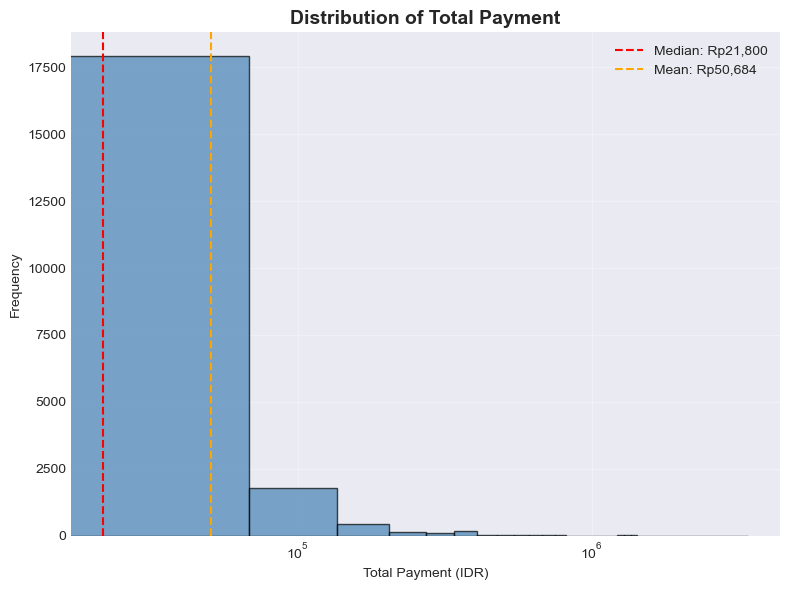

Mean: Rp50,684 | Median: Rp21,800


In [9]:
# SECTION 5: EXPLORATORY DATA ANALYSIS (EDA)

# CHART 1: Distribution of Total Payment

plt.figure(figsize=(8, 6))
plt.hist(df['Total Pembayaran'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribution of Total Payment', fontsize=14, fontweight='bold')
plt.xlabel('Total Payment (IDR)')
plt.ylabel('Frequency')
plt.xscale('log')
plt.axvline(df['Total Pembayaran'].median(), color='red', linestyle='--', 
            label=f"Median: Rp{df['Total Pembayaran'].median():,.0f}")
plt.axvline(df['Total Pembayaran'].mean(), color='orange', linestyle='--', 
            label=f"Mean: Rp{df['Total Pembayaran'].mean():,.0f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean: Rp{df['Total Pembayaran'].mean():,.0f} | Median: Rp{df['Total Pembayaran'].median():,.0f}")

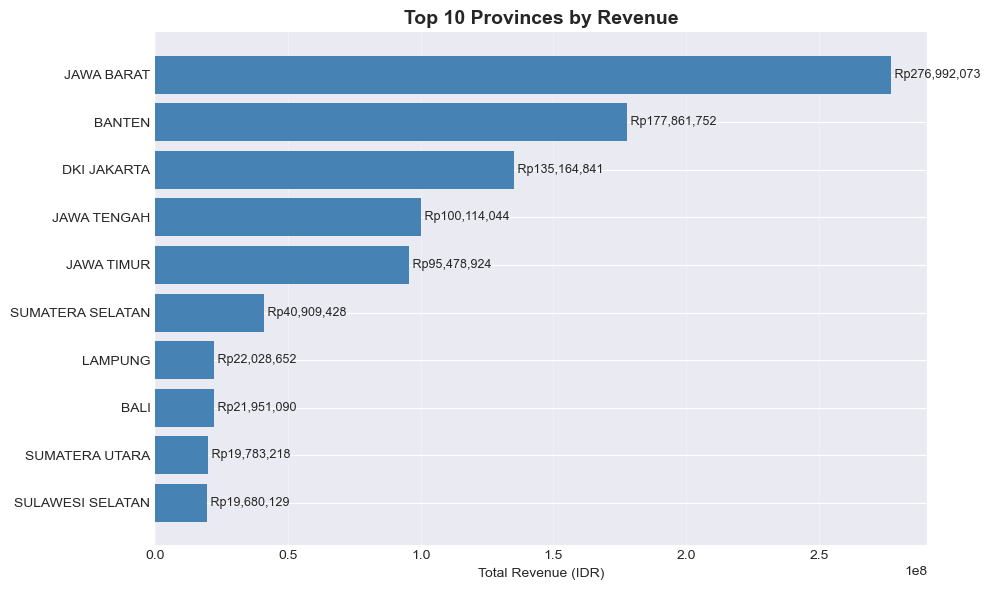

In [11]:
# CHART 2: Top 10 Provinces by Revenue

top_provinces = df.groupby('Provinsi')['Total Pembayaran'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_provinces)), top_provinces.values, color='steelblue')
plt.yticks(range(len(top_provinces)), top_provinces.index)
plt.title('Top 10 Provinces by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (IDR)')
plt.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(top_provinces.values):
    plt.text(v, i, f' Rp{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

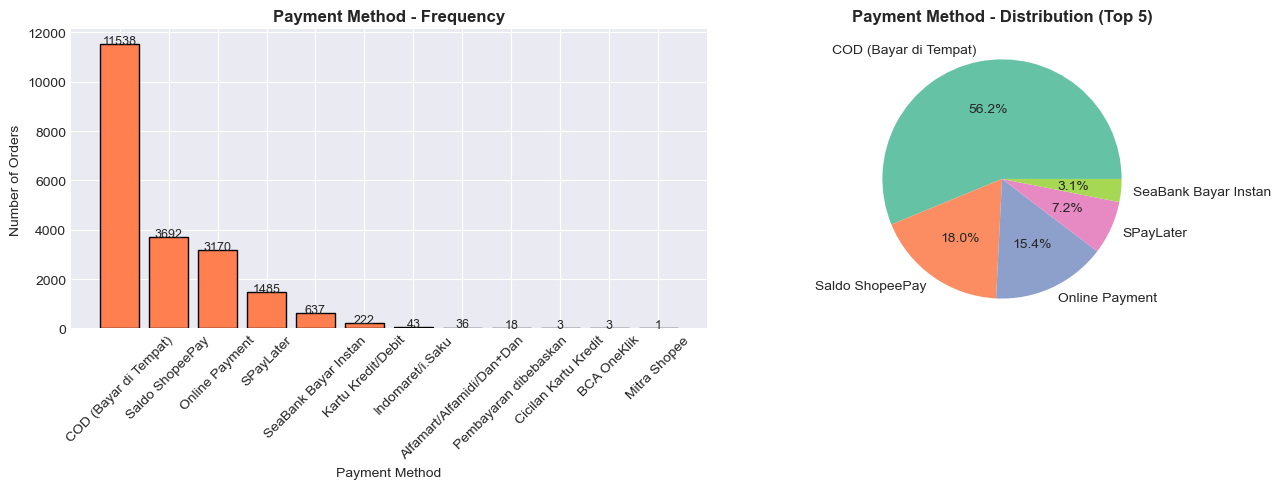

Digital payment share: 20.8% | COD share: 55.3%


In [13]:
# CHART 3: Payment Method Distribution

payment_counts = df['Metode Pembayaran'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(payment_counts.index, payment_counts.values, color='coral', edgecolor='black')
axes[0].set_title('Payment Method - Frequency', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(payment_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Pie chart
axes[1].pie(payment_counts.values[:5], labels=payment_counts.index[:5], autopct='%1.1f%%')
axes[1].set_title('Payment Method - Distribution (Top 5)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

digital_share = df[df['payment_group'] == 'Digital'].shape[0] / df.shape[0] * 100
cod_share = df[df['payment_group'] == 'COD'].shape[0] / df.shape[0] * 100
print(f"Digital payment share: {digital_share:.1f}% | COD share: {cod_share:.1f}%")

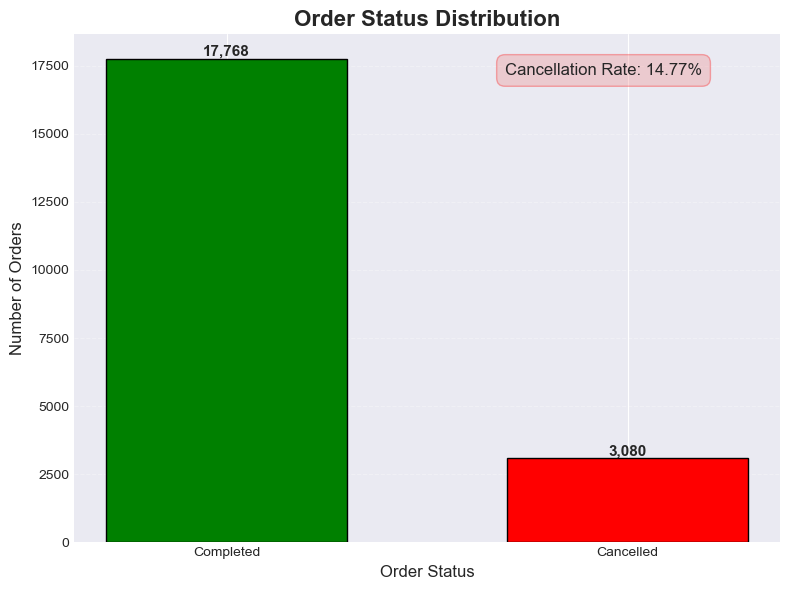

Completion Rate: 85.23% | Cancellation Rate: 14.77%


In [15]:
# CHART 4: Order Status Distribution

status_counts = df['Order_Status_Group'].value_counts()
colors = ['green', 'red']

plt.figure(figsize=(8, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=colors, edgecolor='black', width=0.6)
plt.title('Order Status Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{int(height):,}', 
             ha='center', fontsize=11, fontweight='bold')

cancel_rate = (status_counts['Cancelled'] / status_counts.sum()) * 100

plt.text(0.75, 0.92, f'Cancellation Rate: {cancel_rate:.2f}%',
         fontsize=12, transform=plt.gca().transAxes, ha='center',
         bbox=dict(facecolor='lightcoral', alpha=0.3, edgecolor='red', boxstyle='round,pad=0.5'))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Completion Rate: {100 - cancel_rate:.2f}% | Cancellation Rate: {cancel_rate:.2f}%")

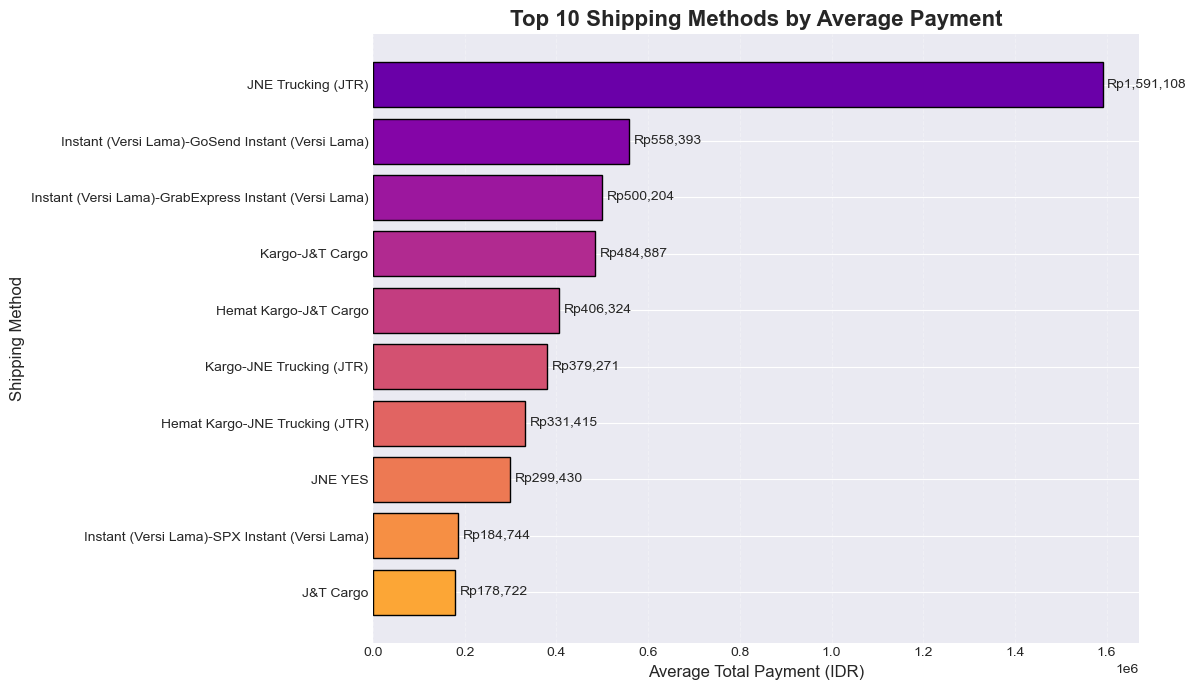

In [17]:
# CHART 5: Average Payment by Shipping Method

shipping_payment = df.groupby('Opsi Pengiriman')['Total Pembayaran'].mean().sort_values(ascending=False)
shipping_payment = shipping_payment[shipping_payment > 0].head(10)

plt.figure(figsize=(12, 7))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(shipping_payment)))
bars = plt.barh(shipping_payment.index, shipping_payment.values, color=colors, edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 10 Shipping Methods by Average Payment', fontsize=16, fontweight='bold')
plt.xlabel('Average Total Payment (IDR)', fontsize=12)
plt.ylabel('Shipping Method', fontsize=12)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10000, bar.get_y() + bar.get_height()/2, f'Rp{width:,.0f}', 
             va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

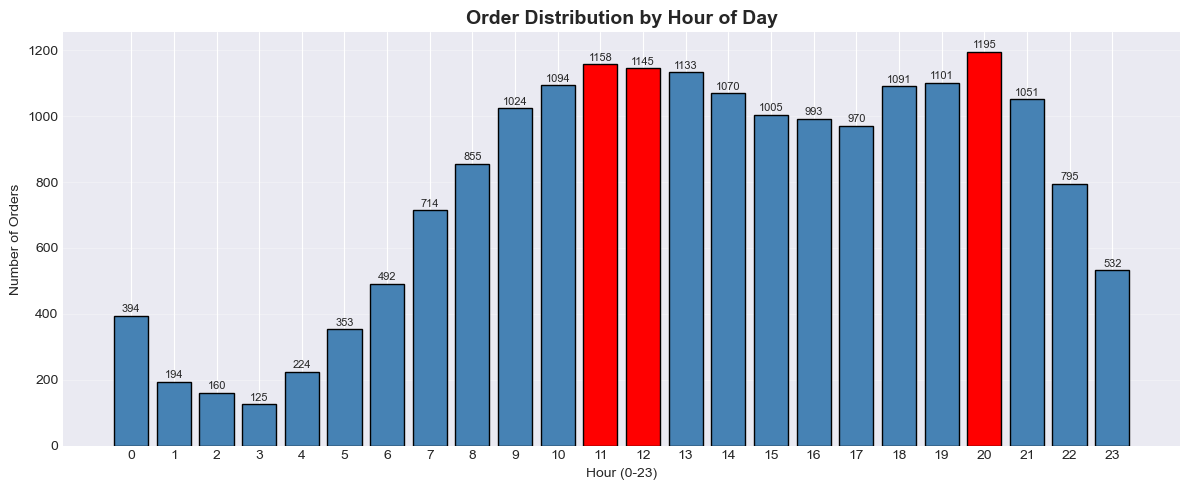

Peak order hours: [20.0, 11.0, 12.0]


In [19]:
# CHART 6: Order Distribution by Hour

if df['Hour'].notna().sum() > 0:
    hourly_orders = df.groupby('Hour').size()
    
    plt.figure(figsize=(12, 5))
    peak_hours = hourly_orders.nlargest(3).index.tolist()
    colors = ['red' if hour in peak_hours else 'steelblue' for hour in hourly_orders.index]
    bars = plt.bar(hourly_orders.index, hourly_orders.values, color=colors, edgecolor='black')
    plt.title('Order Distribution by Hour of Day', fontsize=14, fontweight='bold')
    plt.xlabel('Hour (0-23)')
    plt.ylabel('Number of Orders')
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}', 
                     ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    print(f"Peak order hours: {peak_hours}")
else:
    print("Skipping Hour chart: No valid datetime data available")

Digital Payment: 4329 orders | Mean: Rp64,003
COD: 11538 orders | Mean: Rp35,420

T-Test Results:
  T-statistic: 9.8138
  P-value: 0.000000
  Cohen's d: 0.239
  Digital users spend 80.7% MORE than COD users

Result: STATISTICALLY SIGNIFICANT (p < 0.05)
→ Digital payment users have significantly higher transaction value


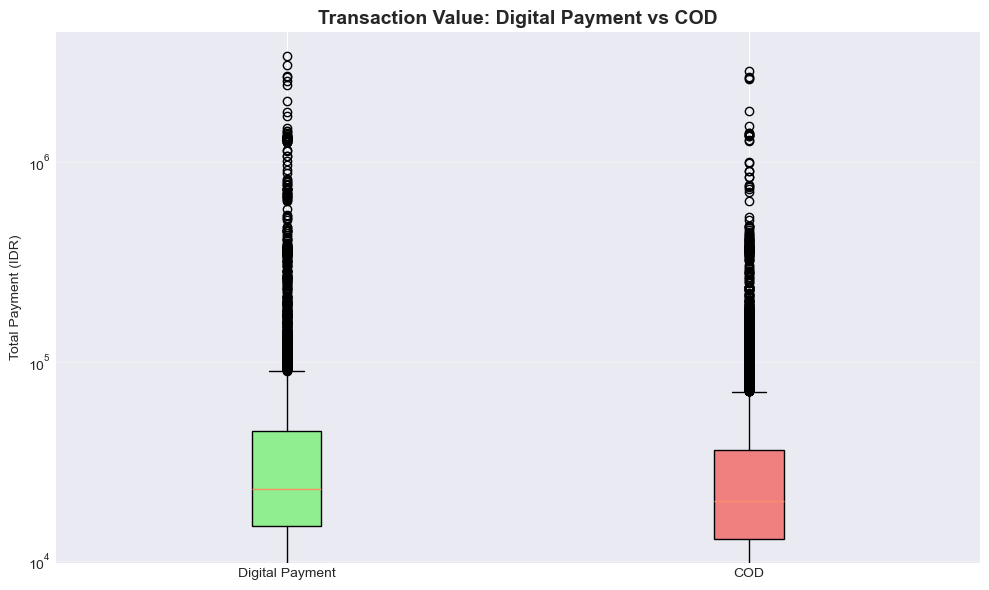

In [21]:
# SECTION 6: STATISTICAL ANALYSIS 

ab_df = df[df['payment_group'].isin(['Digital', 'COD'])].copy()

digital_vals = ab_df[ab_df['payment_group'] == 'Digital']['Total Pembayaran'].values
cod_vals = ab_df[ab_df['payment_group'] == 'COD']['Total Pembayaran'].values

print(f"Digital Payment: {len(digital_vals)} orders | Mean: Rp{digital_vals.mean():,.0f}")
print(f"COD: {len(cod_vals)} orders | Mean: Rp{cod_vals.mean():,.0f}")

# T-Test
t_stat, p_value = ttest_ind(digital_vals, cod_vals, equal_var=False)

# Effect size (Cohen's d)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (mean1 - mean2) / pooled_std

effect_size = cohens_d(digital_vals, cod_vals)
lift_pct = ((digital_vals.mean() - cod_vals.mean()) / cod_vals.mean()) * 100

print(f"\nT-Test Results:")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Cohen's d: {effect_size:.3f}")
print(f"  Digital users spend {lift_pct:.1f}% MORE than COD users")

if p_value < 0.05:
    print(f"\nResult: STATISTICALLY SIGNIFICANT (p < 0.05)")
    print(f"→ Digital payment users have significantly higher transaction value")
else:
    print(f"\nResult: NOT statistically significant")

# Boxplot
plt.figure(figsize=(10, 6))
bp = plt.boxplot([digital_vals, cod_vals], labels=['Digital Payment', 'COD'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.title('Transaction Value: Digital Payment vs COD', fontsize=14, fontweight='bold')
plt.ylabel('Total Payment (IDR)')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Cancellation rate: 14.77%

Top 5 Provinces by Cancellation Rate:
                                    mean  count
Provinsi                                       
SULAWESI TENGAH                 0.357143     56
SULAWESI UTARA                  0.341463     41
KALIMANTAN TIMUR                0.308271    133
KALIMANTAN TENGAH               0.305970    134
NANGGROE ACEH DARUSSALAM (NAD)  0.290076    131

Correlation: Shipping Cost vs Cancellation = -0.122 (p-value: 0.0000)


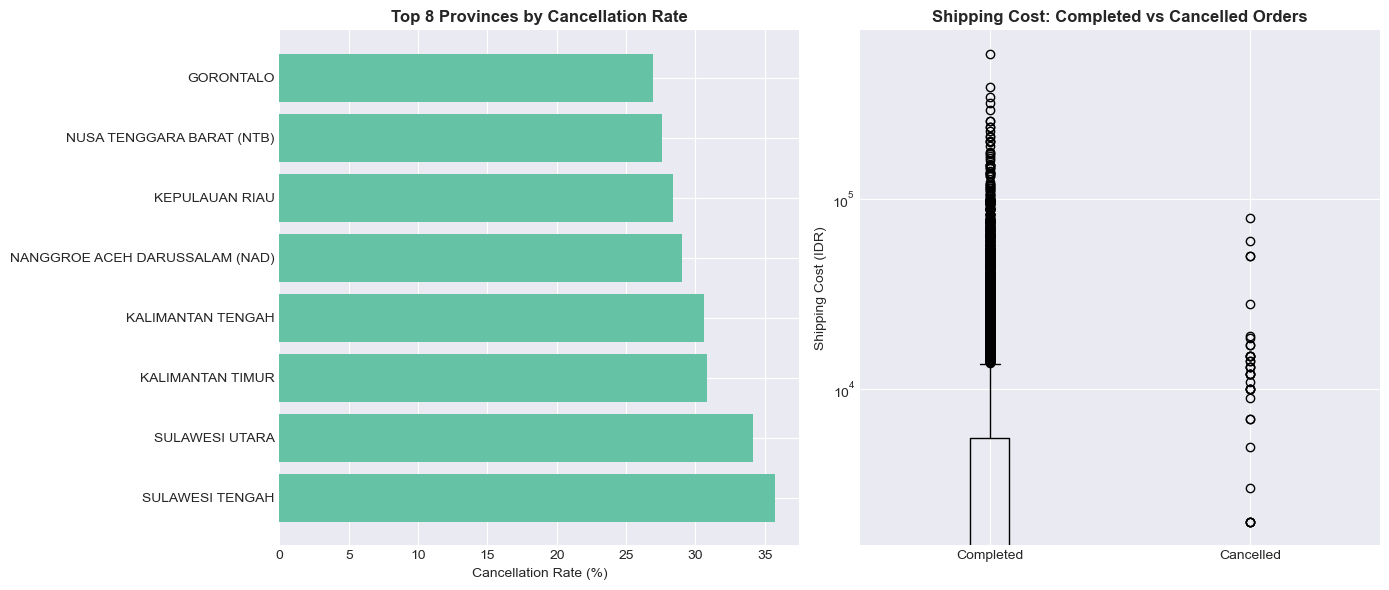

In [23]:
# SECTION 7: CANCELLATION & OPERATIONAL RISK ANALYSIS

cancel_rate = df['Is_Cancelled'].mean() * 100
print(f"Cancellation rate: {cancel_rate:.2f}%")

# Cancellation by province
cancel_by_province = df.groupby('Provinsi')['Is_Cancelled'].agg(['mean', 'count'])
cancel_by_province = cancel_by_province[cancel_by_province['count'] >= 30].sort_values('mean', ascending=False)

print("\nTop 5 Provinces by Cancellation Rate:")
print(cancel_by_province.head(5))

# Correlation: Shipping Cost vs Cancellation
if 'Ongkos Kirim Dibayar oleh Pembeli' in df.columns:
    corr, p_val = pearsonr(df['Ongkos Kirim Dibayar oleh Pembeli'], df['Is_Cancelled'])
    print(f"\nCorrelation: Shipping Cost vs Cancellation = {corr:.3f} (p-value: {p_val:.4f})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_cancel = cancel_by_province.head(8)
axes[0].barh(range(len(top_cancel)), top_cancel['mean'].values * 100)
axes[0].set_yticks(range(len(top_cancel)))
axes[0].set_yticklabels(top_cancel.index)
axes[0].set_title('Top 8 Provinces by Cancellation Rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cancellation Rate (%)')

if 'Ongkos Kirim Dibayar oleh Pembeli' in df.columns:
    axes[1].boxplot([df[df['Is_Cancelled']==0]['Ongkos Kirim Dibayar oleh Pembeli'],
                     df[df['Is_Cancelled']==1]['Ongkos Kirim Dibayar oleh Pembeli']],
                    labels=['Completed', 'Cancelled'])
    axes[1].set_title('Shipping Cost: Completed vs Cancelled Orders', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Shipping Cost (IDR)')
    axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

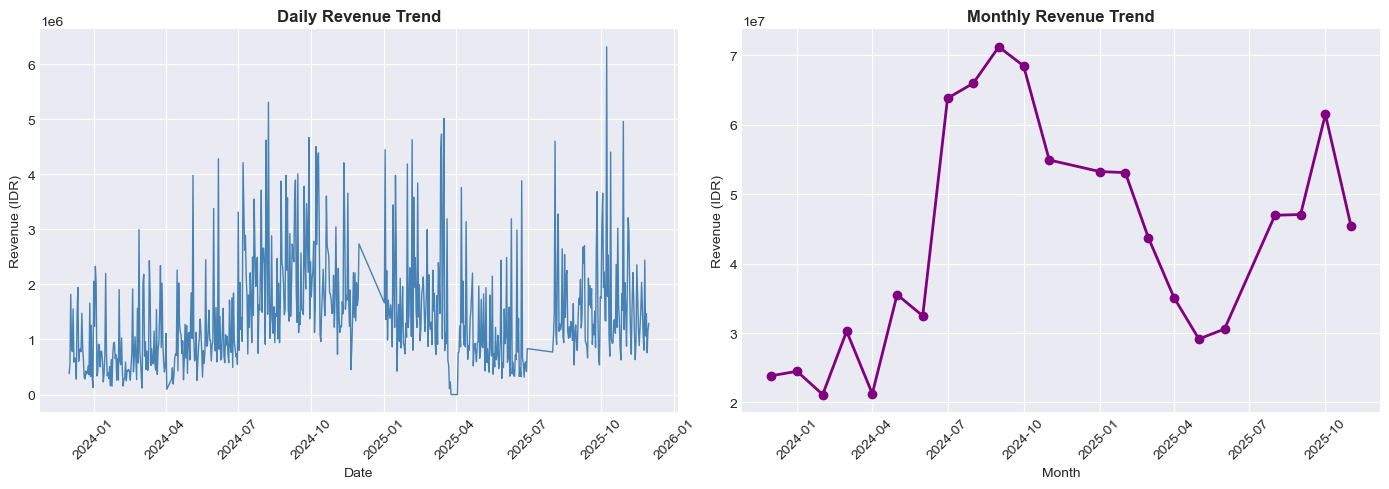

Date range: 2023-12-01 to 2025-11-30
Total days: 661


In [25]:
# SECTION 8: TIME SERIES ANALYSIS

if df['Waktu Pesanan Dibuat'].notna().sum() > 0:
    # Daily sales
    daily_sales = df.groupby('Date')['Total Pembayaran'].sum().reset_index()
    daily_sales.columns = ['date', 'revenue']
    daily_sales = daily_sales.sort_values('date')
    
    # Monthly sales
    monthly_sales = df.groupby(['Year', 'Month'])['Total Pembayaran'].sum().reset_index()
    monthly_sales['date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(day=1))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(daily_sales['date'], daily_sales['revenue'], linewidth=1, color='steelblue')
    axes[0].set_title('Daily Revenue Trend', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Revenue (IDR)')
    axes[0].tick_params(axis='x', rotation=45)
    
    axes[1].plot(monthly_sales['date'], monthly_sales['Total Pembayaran'], marker='o', linewidth=2, color='purple')
    axes[1].set_title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Revenue (IDR)')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Date range: {daily_sales['date'].min()} to {daily_sales['date'].max()}")
    print(f"Total days: {len(daily_sales)}")
else:
    print("SKIPPED: No valid datetime data available for time series analysis")

Analyzing 27 provinces with ≥30 orders
Silhouette Score: 0.356


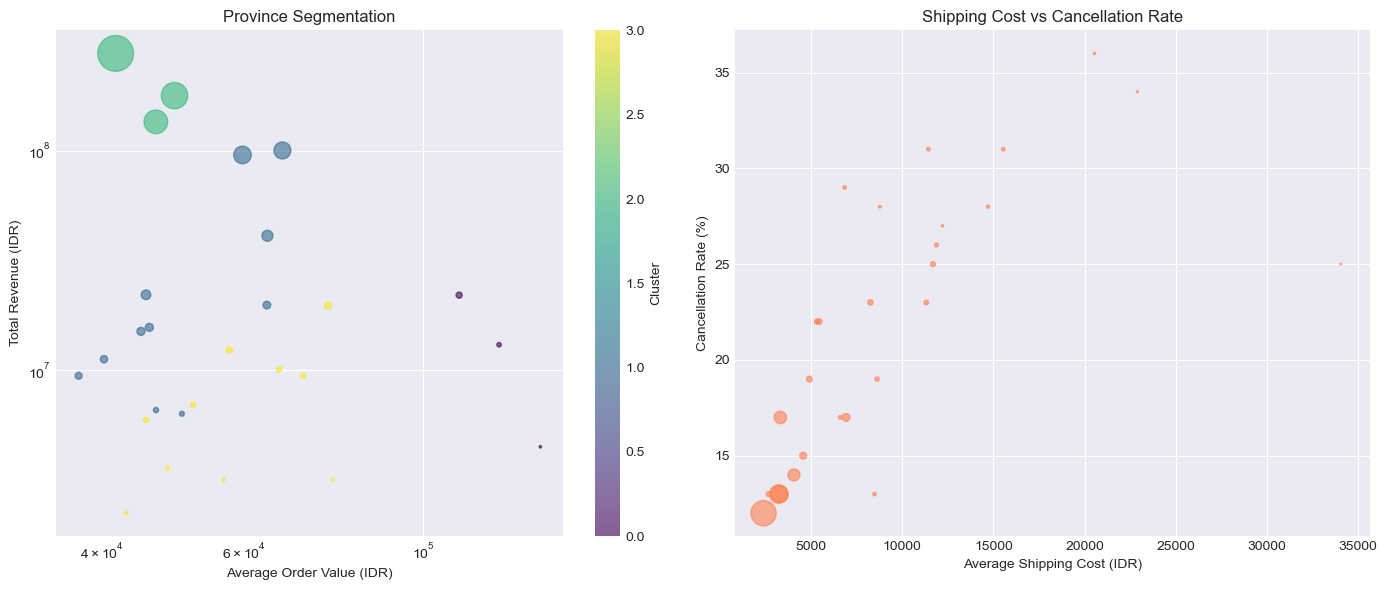


CLUSTER SUMMARY
        avg_order_value  total_revenue cancellation_rate avg_shipping_cost
cluster                                                                   
0             Rp124,980   Rp13,157,519             24.0%          Rp19,125
1              Rp51,364   Rp31,138,279             17.0%           Rp5,504
2              Rp45,788  Rp196,672,889             13.0%           Rp2,967
3              Rp59,321    Rp7,658,238             29.0%          Rp13,313


In [51]:
# SECTION 9: REGIONAL REVENUE & LOGISTICS ANALYSIS

# Province-level metrics
province_metrics = df.groupby('Provinsi').agg({
    'Total Pembayaran': ['sum', 'mean', 'count'],
    'Ongkos Kirim Dibayar oleh Pembeli': 'mean',
    'Is_Cancelled': 'mean'
}).round(2)

province_metrics.columns = ['total_revenue', 'avg_order_value', 'order_count', 
                            'avg_shipping_cost', 'cancellation_rate']
province_metrics = province_metrics.reset_index()
province_metrics = province_metrics[province_metrics['order_count'] >= 30]

print(f"Analyzing {len(province_metrics)} provinces with ≥30 orders")

# K-Means Clustering
if len(province_metrics) >= 4:
    features_for_cluster = ['avg_order_value', 'total_revenue', 'cancellation_rate', 'avg_shipping_cost']
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(province_metrics[features_for_cluster])
    
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    province_metrics['cluster'] = kmeans.fit_predict(scaled_features)
    
    print(f"Silhouette Score: {silhouette_score(scaled_features, kmeans.labels_):.3f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    scatter = axes[0].scatter(province_metrics['avg_order_value'], province_metrics['total_revenue'],
                               c=province_metrics['cluster'], cmap='viridis', 
                               s=province_metrics['order_count']/10, alpha=0.6)
    axes[0].set_xlabel('Average Order Value (IDR)')
    axes[0].set_ylabel('Total Revenue (IDR)')
    axes[0].set_title('Province Segmentation')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    plt.colorbar(scatter, ax=axes[0], label='Cluster')
    
    axes[1].scatter(province_metrics['avg_shipping_cost'], province_metrics['cancellation_rate'] * 100,
                    s=province_metrics['order_count']/20, alpha=0.6, color='coral')
    axes[1].set_xlabel('Average Shipping Cost (IDR)')
    axes[1].set_ylabel('Cancellation Rate (%)')
    axes[1].set_title('Shipping Cost vs Cancellation Rate')
    
    plt.tight_layout()
    plt.show()
    
    
    # CREATE CLUSTER SUMMARY (FIXED)
    
    
    # Create cluster_summary from province_metrics
    cluster_summary = province_metrics.groupby('cluster')[features_for_cluster].mean().round(2)
    
    # CLUSTER SUMMARY (FORMATTED OUTPUT)
    cluster_summary_display = cluster_summary.copy()
    cluster_summary_display['avg_order_value'] = cluster_summary_display['avg_order_value'].apply(lambda x: f"Rp{x:,.0f}")
    cluster_summary_display['total_revenue'] = cluster_summary_display['total_revenue'].apply(lambda x: f"Rp{x:,.0f}")
    cluster_summary_display['cancellation_rate'] = (cluster_summary_display['cancellation_rate'] * 100).apply(lambda x: f"{x:.1f}%")
    cluster_summary_display['avg_shipping_cost'] = cluster_summary_display['avg_shipping_cost'].apply(lambda x: f"Rp{x:,.0f}")
    
    print("\n" + "=" * 75)
    print("CLUSTER SUMMARY")
    print("=" * 75)
    print(cluster_summary_display.to_string())
    
else:
    print("Not enough provinces for clustering (need at least 4)")

In [29]:
# SECTION 10: BUSINESS INSIGHTS & RECOMMENDATIONS

total_revenue = df['Total Pembayaran'].sum()
cancel_rate = df['Is_Cancelled'].mean()

print("=" * 60)
print("KEY FINDINGS & RECOMMENDATIONS")
print("=" * 60)

print(f"\n1. PAYMENT METHOD INSIGHT")
print(f"   Digital payment users spend {lift_pct:.1f}% more than COD users (p-value: {p_value:.6f})")
print(f"   Recommendation: Launch 'Cashback 5% for Digital Payment' campaign")

print(f"\n2. CANCELLATION INSIGHT")
print(f"   Overall cancellation rate: {cancel_rate*100:.2f}%")
print(f"   Top cancellation provinces: {', '.join(cancel_by_province.head(3).index.tolist())}")
print(f"   Recommendation: Prioritize logistics optimization in high-cancellation provinces")

print(f"\n3. SHIPPING INSIGHT")
highest_shipping = df.groupby('Opsi Pengiriman')['Total Pembayaran'].mean().sort_values(ascending=False).index[0]
print(f"   Highest AOV shipping method: {highest_shipping}")
print(f"   Recommendation: Promote premium shipping for high-value products")

print("\n" + "=" * 60)
print("ESTIMATED BUSINESS IMPACT")
print("=" * 60)

estimated_cancel_reduction = 0.25
potential_savings = total_revenue * cancel_rate * estimated_cancel_reduction
print(f"Potential Savings from Reducing Cancellation by 25%: Rp{potential_savings:,.0f}")

estimated_digital_shift = 0.10
potential_revenue = total_revenue * (lift_pct/100) * estimated_digital_shift
print(f"Potential Revenue from 10% COD to Digital shift: Rp{potential_revenue:,.0f}")

KEY FINDINGS & RECOMMENDATIONS

1. PAYMENT METHOD INSIGHT
   Digital payment users spend 80.7% more than COD users (p-value: 0.000000)
   Recommendation: Launch 'Cashback 5% for Digital Payment' campaign

2. CANCELLATION INSIGHT
   Overall cancellation rate: 14.77%
   Top cancellation provinces: SULAWESI TENGAH, SULAWESI UTARA, KALIMANTAN TIMUR
   Recommendation: Prioritize logistics optimization in high-cancellation provinces

3. SHIPPING INSIGHT
   Highest AOV shipping method: JNE Trucking (JTR)
   Recommendation: Promote premium shipping for high-value products

ESTIMATED BUSINESS IMPACT
Potential Savings from Reducing Cancellation by 25%: Rp39,026,370
Potential Revenue from 10% COD to Digital shift: Rp85,265,326


In [55]:
# SECTION 11: EXPORT FOR TABLEAU DASHBOARD

print("=" * 60)
print("EXPORTING DATA FOR TABLEAU DASHBOARD")
print("=" * 60)

# 1. Daily Sales Data
if 'Date' in df.columns and df['Date'].notna().sum() > 0:
    daily_export = df.groupby('Date').agg({
        'Total Pembayaran': 'sum',
        'total_qty': 'sum',
        'Is_Cancelled': 'mean'
    }).reset_index()
    daily_export.to_csv('tableau_daily_sales.csv', index=False)
    print("✅ Exported: tableau_daily_sales.csv")
else:
    print("⚠️ Skipped: tableau_daily_sales.csv (No date data)")

# 2. Province Analysis (for Map)
if 'province_metrics' in dir() and len(province_metrics) > 0:
    province_export = province_metrics.copy()
    province_export.to_csv('tableau_province_analysis.csv', index=False)
    print("✅ Exported: tableau_province_analysis.csv")
else:
    print("⚠️ Skipped: tableau_province_analysis.csv")

# 3. Payment Analysis
payment_export = df.groupby(['Metode Pembayaran', 'payment_group']).agg({
    'Total Pembayaran': ['mean', 'count'],
    'Is_Cancelled': 'mean'
}).reset_index()
payment_export.columns = ['Metode_Pembayaran', 'payment_group', 'avg_payment', 'order_count', 'cancellation_rate']
payment_export.to_csv('tableau_payment_analysis.csv', index=False)
print("✅ Exported: tableau_payment_analysis.csv")

# 4. Monthly Trends
if 'Year' in df.columns and df['Year'].notna().sum() > 0:
    monthly_export = df.groupby(['Year', 'Month']).agg({
        'Total Pembayaran': 'sum',
        'total_qty': 'sum',
        'Is_Cancelled': 'mean'
    }).reset_index()
    monthly_export.to_csv('tableau_monthly_trends.csv', index=False)
    print("✅ Exported: tableau_monthly_trends.csv")
else:
    print("⚠️ Skipped: tableau_monthly_trends.csv (No date data)")

# 5. Shipping Analysis
shipping_export = df.groupby('Opsi Pengiriman').agg({
    'Total Pembayaran': ['mean', 'count'],
    'Is_Cancelled': 'mean',
    'Ongkos Kirim Dibayar oleh Pembeli': 'mean'
}).reset_index()
shipping_export.columns = ['Opsi_Pengiriman', 'avg_payment', 'order_count', 'cancellation_rate', 'avg_shipping_cost']
shipping_export = shipping_export.sort_values('avg_payment', ascending=False)
shipping_export.to_csv('tableau_shipping_analysis.csv', index=False)
print("✅ Exported: tableau_shipping_analysis.csv")

EXPORTING DATA FOR TABLEAU DASHBOARD
✅ Exported: tableau_daily_sales.csv
✅ Exported: tableau_province_analysis.csv
✅ Exported: tableau_payment_analysis.csv
✅ Exported: tableau_monthly_trends.csv
✅ Exported: tableau_shipping_analysis.csv

✅ 5 FILES EXPORTED SUCCESSFULLY!
